<a href="https://colab.research.google.com/github/nattaponm/Teach_Nowcast_Pysteps_TMD/blob/main/notebooks/03_deterministic_nowcast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3: Deterministic nowcasting ของพายุพาความร้อน
### Extrapolation vs S-PROG, multi-issue-time verification and GeoTIFF export

⏱️ เวลาเรียนโดยประมาณ **75–90 นาที** | ต้องผ่าน: Notebook 0–2

---
## 🎯 วัตถุประสงค์การเรียนรู้
เมื่อจบ notebook นี้ นิสิตจะสามารถ
1. **สร้าง deterministic nowcast** ด้วย Eulerian persistence, extrapolation และ S-PROG บนข้อมูล TMD
2. **อธิบาย** ว่าทำไม S-PROG จึง "ลบ" รายละเอียดเซลล์เล็กอย่างรวดเร็วเมื่อข้อมูลห่าง 15 นาที
3. **ประเมินผลจากหลาย issue time** ด้วย ETS และ **FSS** (spatial verification)
4. **ส่งออก** nowcast เป็น GeoTIFF เพื่อใช้ใน QGIS/ArcGIS

## 📖 1. แนวคิดและสมการ

### 1.1 วิธีที่เปรียบเทียบ
| วิธี | แนวคิด | บทบาท |
|---|---|---|
| **Eulerian persistence** | ใช้ภาพล่าสุดเป็นคำพยากรณ์ทุก lead time (ไม่เลื่อน) | baseline ที่ทุกวิธี "ต้องชนะ" |
| **Extrapolation** | เลื่อนภาพล่าสุดตาม motion field (LK) | Lagrangian persistence |
| **S-PROG** | แยกสเกล (cascade) + AR(2) ต่อสเกล ให้สเกลเล็กจางตามอายุ | ลดความผิดพลาดจากรายละเอียดที่พยากรณ์ไม่ได้ |

### 1.2 S-PROG กับข้อมูลทุก 15 นาที
AR(2) ของแต่ละ cascade level $j$:

$$
\Psi_j(t) = \phi_{j,1}\,\Psi_j(t-1) + \phi_{j,2}\,\Psi_j(t-2)
$$

ค่าสัมประสิทธิ์มาจาก **autocorrelation ที่ lag 1 time step** ($\rho_{j,1}$) ถ้าภาพห่าง 15 นาที เซลล์เล็กจะเปลี่ยนไปมากจน $\rho_{j,1} \approx 0$ ซึ่งแปลว่าสเกลนั้น **หายไปทันทีตั้งแต่ lead time แรก** (ดูตาราง "Correlation coefficients" ที่ S-PROG พิมพ์ออกมา)

### 1.3 Verification จากหลาย issue time
มีข้อมูลเพียง 13 ภาพ จึงออกพยากรณ์ **ทุก 15 นาที ตั้งแต่ 11:45 ถึง 13:00 UTC (6 ครั้ง)** แล้ว **รวม contingency table** ของทุกครั้งก่อนคำนวณคะแนน ซึ่งน่าเชื่อถือกว่าการดูครั้งเดียว

**Fractions Skill Score (FSS)** เปรียบเทียบสัดส่วนพื้นที่ฝนเกิน threshold ภายในหน้าต่างขนาด $L$

$$
\mathrm{FSS}(L) = 1 - \frac{\sum (P_f - P_o)^2}{\sum P_f^2 + \sum P_o^2},
\qquad
\mathrm{FSS}_{\text{useful}} = 0.5 + \frac{f_o}{2}
$$

ซึ่ง **ไม่ลงโทษการผิดตำแหน่งเล็กน้อย** (น้อยกว่า $L$) จึงเหมาะกับพายุเซลล์เล็กมากกว่า ETS

## ⚙️ 2. เตรียมสภาพแวดล้อมและข้อมูล

In [1]:
#@title ⚙️ Setup: ติดตั้ง pysteps และดาวน์โหลดข้อมูล TMD (รันก่อนเสมอ ~2-3 นาทีใน Colab)
import os, sys, warnings
warnings.filterwarnings("ignore")

REPO = "Teach_Nowcast_Pysteps_TMD"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q pysteps==1.21.5 cartopy netCDF4 rasterio geopandas
    if not os.path.exists(REPO):
        !git clone -q --depth 1 https://github.com/nattaponm/{REPO}.git

# หาโฟลเดอร์หลักของ repo (ที่มี utils/ และ data/)
for ROOT in [REPO, ".", ".."]:
    if os.path.exists(os.path.join(ROOT, "utils", "tmd_tools.py")):
        break
ROOT = os.path.abspath(ROOT)
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, "data")

import numpy as np
import matplotlib.pyplot as plt
import pysteps
from utils.data_io import load_radar_nc
from utils import mapplot as mp
from utils import tmd_tools as tt
mp.set_style()
mp.BASEMAP.update(provinces=True, rivers=True, lakes=False)   # จังหวัด + แม่น้ำโขง
mp.POINTS[:] = tt.POIS                                         # เรดาร์ เชียงของ เชียงแสน
print("✅ พร้อมใช้งาน | ข้อมูลอยู่ที่:", DATA)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.9/686.9 kB 12.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.4 MB/s eta 0:00:00
Pysteps configuration file found at: /usr/local/lib/python3.13/dist-packages/pysteps/pystepsrc

✅ พร้อมใช้งาน | ข้อมูลอยู่ที่: /content/Teach_Nowcast_Pysteps_TMD/data


In [2]:
from pysteps import motion, nowcasts, verification
from pysteps.utils import transformation

R, meta = load_radar_nc(os.path.join(DATA, "tmd_cri_20200423_rain_1km.nc"))
ts = meta["timestamps"]
DT = meta["accutime"]
BOX = tt.range_box(meta, 165)
radar_mask = np.isfinite(R[0])
N_LEAD = 4                                       # +15, +30, +45, +60 นาที
lead_min = (np.arange(N_LEAD) + 1) * DT
ISSUES = list(range(3, 9))                       # 11:45 … 13:00 UTC
print("issue times:", [ts[i].strftime("%H:%M") for i in ISSUES])

def to_dbr(x):
    d, m = transformation.dB_transform(x, meta, threshold=0.1, zerovalue=-15.0)
    d[~np.isfinite(d)] = -15.0
    return d, m

def to_mmh(d, m):
    r = transformation.dB_transform(d, threshold=m["threshold"], inverse=True)[0]
    r[..., ~radar_mask] = np.nan
    return r

issue times: ['11:45', '12:00', '12:15', '12:30', '12:45', '13:00']


## 💻 3. ฟังก์ชันสร้าง nowcast สำหรับ issue time ใด ๆ

In [3]:
import contextlib, io
extrap = nowcasts.get_method("extrapolation")
sprog = nowcasts.get_method("sprog")

def make_nowcasts(i, verbose=False):
    """คืนค่า dict ของ nowcast (N_LEAD, y, x) [mm/h] ที่ออก ณ ts[i] โดยใช้ภาพ i-3 … i"""
    d, m = to_dbr(R[i - 3:i + 1])
    V = motion.get_method("LK")(d, verbose=False)
    out = {"Persistence": np.repeat(R[i][None], N_LEAD, axis=0)}
    out["Extrapolation"] = to_mmh(extrap(d[-1], V, N_LEAD), m)
    sink = contextlib.nullcontext() if verbose else contextlib.redirect_stdout(io.StringIO())
    with sink:                                  # ปิดข้อความยาวของ S-PROG เมื่อ verbose=False
        out["S-PROG"] = to_mmh(sprog(d[-3:], V, N_LEAD, n_cascade_levels=6,
                                     precip_thr=m["threshold"]), m)
    return out, V

fc12, V12 = make_nowcasts(4, verbose=True)    # ตัวอย่าง: ออกพยากรณ์ 12:00 UTC (ดูตาราง correlation)
obs12 = R[5:5 + N_LEAD]

Computing S-PROG nowcast
------------------------

Inputs
------
input dimensions: 483x483

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
conditional statistics: no
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     4
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
precip. intensity threshold: -10.0
Rain fraction is: 0.012838153534885915, while minimum fraction is 0.0
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------
| Level |     Lag-1     |     Lag-2     |
-----------------------------------------
| 1     | 0.995764      | 0.971272      |
-----------------------------------------
| 2     | 0.964256      | 0.849853      |
------------------------------------

### แผนที่: issue time 12:00 UTC

บันทึกรูปแล้ว: figures/nb3_fig01_nowcasts_1200.png, figures/nb3_fig01_nowcasts_1200.pdf


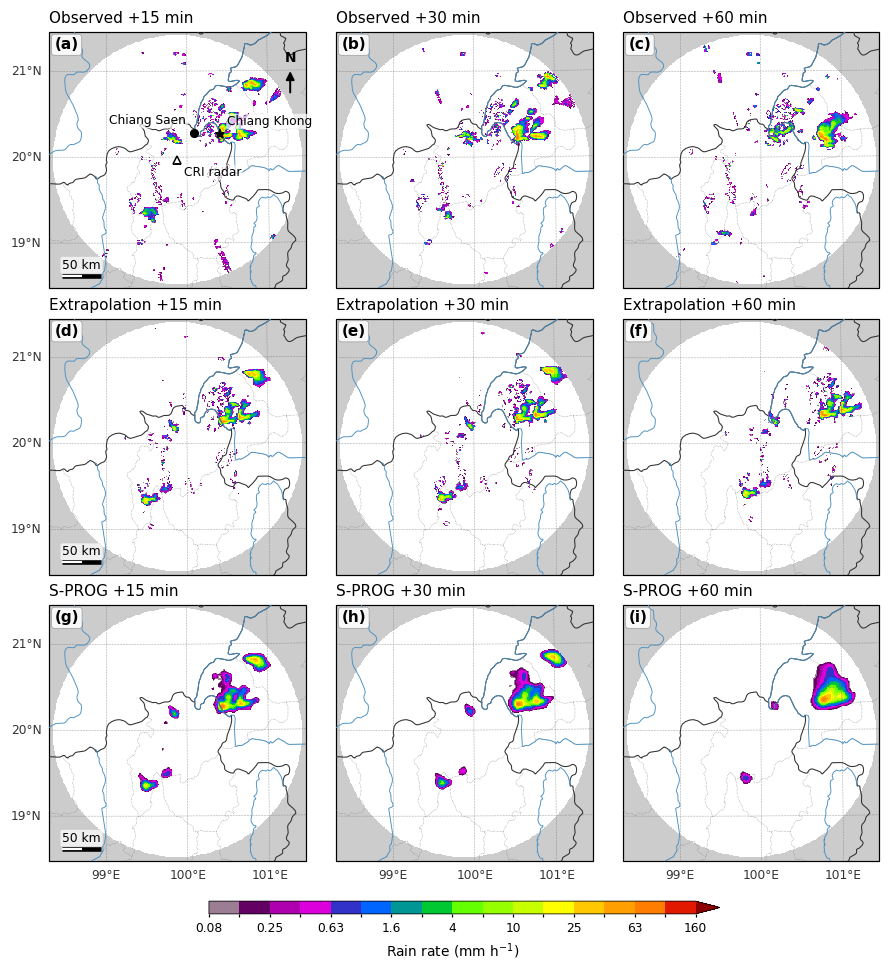

In [4]:
rows = [("Observed", obs12), ("Extrapolation", fc12["Extrapolation"]), ("S-PROG", fc12["S-PROG"])]
leads = [0, 1, 3]                             # +15, +30, +60
fig, axs = mp.map_panels(3, 3, meta, panel_width=2.7, zoom=BOX)
for r, (name, data) in enumerate(rows):
    for c, k in enumerate(leads):
        lab = tuple(s for s, ok in (("left", c == 0), ("bottom", r == 2)) if ok)
        im = mp.radar_map(axs[r * 3 + c], data[k], meta, title=f"{name} +{int(lead_min[k])} min",
                          zoom=BOX, gridline_labels=lab, north=(r == 0 and c == 0),
                          scalebar=(c == 0), points=(r == 0 and c == 0))
mp.add_colorbar(fig, im, axs)
mp.panel_labels(axs)
mp.save_figure(fig, "nb3_fig01_nowcasts_1200")
plt.show()

> 🔍 **สังเกต:** S-PROG ลบเซลล์เล็กออกเกือบหมดตั้งแต่ +30 นาที เหลือเพียงกลุ่มพายุใหญ่ที่ "จาง" และกว้างขึ้น ซึ่งสอดคล้องกับค่า autocorrelation ใกล้ศูนย์ของ cascade level เล็กในตารางด้านบน

## 📏 4. Verification จาก 6 issue time
ใช้ฟังก์ชัน **accumulator** ของ pysteps (`*_init` → `*_accum` → `*_compute`) เพื่อรวมสถิติจากทุก issue time

In [5]:
methods = ["Persistence", "Extrapolation", "S-PROG"]
THRS = [1.0, 10.0]                               # mm/h (10 mm/h ≈ 39 dBZ ด้วย Marshall–Palmer)
FSS_SCALE = 20                                   # หน้าต่าง 20 km
ct = {(m, thr, k): verification.det_cat_fct_init(thr) for m in methods for thr in THRS for k in range(N_LEAD)}
fs = {(m, k): verification.fss_init(10.0, FSS_SCALE) for m in methods for k in range(N_LEAD)}
all_fc = {}

for i in ISSUES:
    fc, _ = make_nowcasts(i)
    all_fc[i] = fc
    for k in range(N_LEAD):
        obs = R[i + 1 + k]
        for m in methods:
            for thr in THRS:
                verification.det_cat_fct_accum(ct[(m, thr, k)], fc[m][k], obs)
            verification.fss_accum(fs[(m, k)], np.nan_to_num(fc[m][k]), np.nan_to_num(obs))
print("คำนวณครบ", len(ISSUES), "issue times")

คำนวณครบ 6 issue times


บันทึกรูปแล้ว: figures/nb3_fig02_verification.png, figures/nb3_fig02_verification.pdf


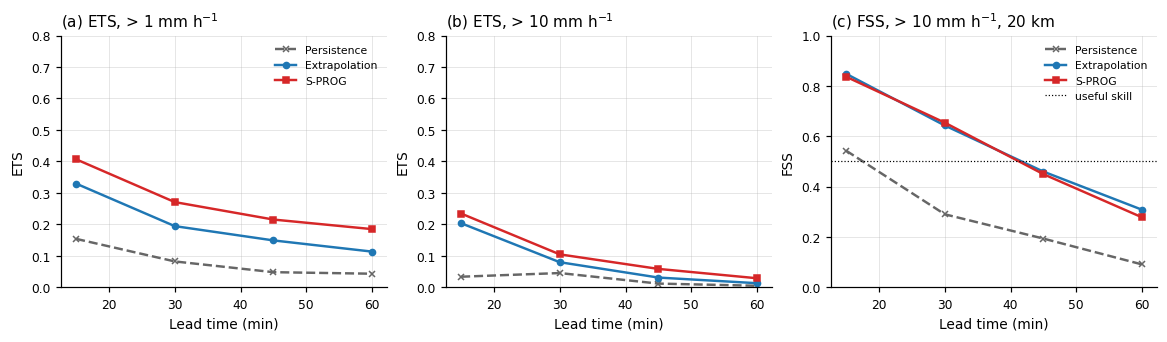

In [6]:
style = {"Persistence": dict(color="0.4", ls="--", marker="x"),
         "Extrapolation": dict(color="#1f77b4", marker="o"),
         "S-PROG": dict(color="#d62728", marker="s")}
fig, axs = plt.subplots(1, 3, figsize=(10.5, 3), layout="constrained")
for ax, thr, lab in zip(axs[:2], THRS, "ab"):
    for m in methods:
        ets = [verification.det_cat_fct_compute(ct[(m, thr, k)], scores=["ETS"])["ETS"] for k in range(N_LEAD)]
        ax.plot(lead_min, ets, ms=4, label=m, **style[m])
    mp.skill_axes(ax, ylabel="ETS", ylim=(0, 0.8), title=f"({lab}) ETS, > {thr:g} mm h$^{{-1}}$")
for m in methods:
    axs[2].plot(lead_min, [verification.fss_compute(fs[(m, k)]) for k in range(N_LEAD)], ms=4, label=m, **style[m])
fo = np.nanmean([np.nanmean(R[i] >= 10) for i in range(4, 13)])
axs[2].axhline(0.5 + fo / 2, color="k", lw=0.8, ls=":", label="useful skill")
mp.skill_axes(axs[2], ylabel="FSS", ylim=(0, 1), title=f"(c) FSS, > 10 mm h$^{{-1}}$, {FSS_SCALE} km")
axs[0].legend(frameon=False, fontsize=7)
axs[2].legend(frameon=False, fontsize=7, loc="upper right")
mp.save_figure(fig, "nb3_fig02_verification")
plt.show()

> 🔍 **การตีความ:**
> - ทุกวิธีเสื่อมเร็วมาก เพราะพายุพาความร้อนมีอายุสั้นและข้อมูลห่าง 15 นาที (ข้อมูลยุโรปใน repo ตัวอย่างยังมีทักษะที่ +60 นาที)
> - **Extrapolation ดีกว่า persistence** ชัดเจนที่ lead time แรก ซึ่งแสดงว่าการเคลื่อนที่ของพายุ (motion) คือข้อมูลที่มีค่าที่สุดในช่วงแรก
> - คะแนนที่ threshold ฝนหนัก (10 mm/h) ต่ำกว่ามาก เพราะเป็นแกนของเซลล์ที่เล็กและเปลี่ยนเร็ว
> - S-PROG ได้ ETS สูงกว่า extrapolation เล็กน้อย (ไม่เสี่ยงพยากรณ์เซลล์เล็กผิดตำแหน่ง) แต่ FSS ใกล้เคียงกัน
> - เส้น "useful skill" ของ FSS บอกว่าที่สเกล 20 km nowcast ยัง "มีประโยชน์" ถึงประมาณ **+40 นาที** เท่านั้น

## 💾 5. Export nowcast เป็น GeoTIFF (หลาย band)
แต่ละ band = 1 lead time ซึ่งเปิดใน QGIS ได้ทันทีด้วยพิกัด UTM 47N เดียวกับข้อมูล TMD

In [7]:
import rasterio
from rasterio.transform import from_origin

os.makedirs("output", exist_ok=True)
out_tif = f"output/sprog_nowcast_{ts[4]:%Y%m%d%H%M}UTC.tif"
data = fc12["S-PROG"].astype("float32")
profile = dict(driver="GTiff", height=data.shape[1], width=data.shape[2], count=N_LEAD,
               dtype="float32", crs="EPSG:32647", nodata=np.nan, compress="deflate",
               transform=from_origin(meta["x1"], meta["y2"], meta["xpixelsize"], meta["ypixelsize"]))
with rasterio.open(out_tif, "w", **profile) as dst:
    for k in range(N_LEAD):
        dst.write(data[k], k + 1)
        dst.set_band_description(k + 1, f"+{int(lead_min[k])} min rain rate (mm/h)")
    dst.update_tags(issue_time_utc=ts[4].isoformat(), method="pysteps S-PROG", units="mm/h")
print("บันทึกแล้ว:", out_tif, f"({os.path.getsize(out_tif)/1e3:.0f} kB)")

บันทึกแล้ว: output/sprog_nowcast_202004231200UTC.tif (83 kB)


---
## 🧪 แบบฝึกหัด

### 🧪 แบบฝึกหัด 3.1: POD และ FAR สำหรับฝนหนัก

คำนวณ **POD** และ **FAR** ที่ threshold **10 mm h$^{-1}$** ของทั้ง 3 วิธี (ใช้ contingency table `ct` ที่สะสมไว้แล้ว) พล็อตกราฟ 2 panel เทียบกับ lead time

**คำถาม:** สำหรับงานเตือนภัย ระหว่างพลาดเหตุการณ์ (miss) กับเตือนผิด (false alarm) อย่างใดเสียหายมากกว่า? วิธีใดเหมาะกว่า?

<details>
<summary><b>💡 คำใบ้ (คลิกเพื่อเปิด)</b></summary>

- `verification.det_cat_fct_compute(ct[(m, 10.0, k)], scores=["POD", "FAR"])`
- ใช้ `style[m]` สำหรับสีของแต่ละวิธี

</details>

In [8]:
# ✍️ แบบฝึกหัด 3.1 — เขียนโค้ดของคุณที่นี่ (ลบ # หน้าบรรทัดแล้วเติมส่วนที่เป็น ...)
# fig, axs = plt.subplots(1, 2, figsize=(7.5, 3))
# for m in methods:
#     sc = [verification.det_cat_fct_compute(ct[(m, 10.0, k)], scores=["POD", "FAR"]) for k in range(N_LEAD)]
#     axs[0].plot(lead_min, [s["POD"] for s in sc], label=m)
#     axs[1].plot(...)
# plt.show()

บันทึกรูปแล้ว: figures/nb3_ex31_pod_far.png, figures/nb3_ex31_pod_far.pdf


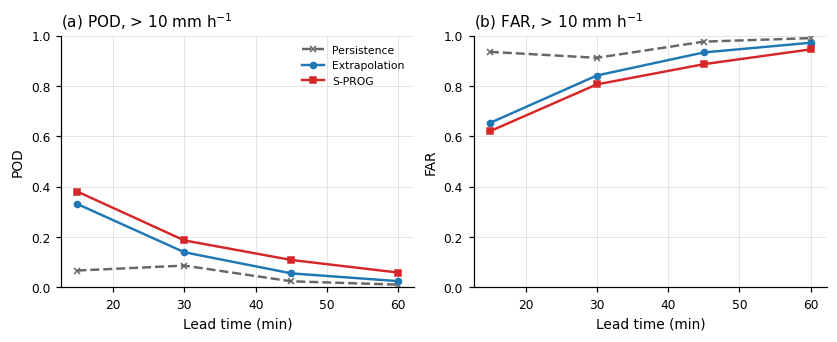

In [9]:
#@title ✅ เฉลยแบบฝึกหัด 3.1 (ลองทำเองก่อน! ดับเบิลคลิกเพื่อดูโค้ด แล้วกด ▶ เพื่อรัน)
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3), layout="constrained")
for m in methods:
    sc = [verification.det_cat_fct_compute(ct[(m, 10.0, k)], scores=["POD", "FAR"]) for k in range(N_LEAD)]
    axs[0].plot(lead_min, [s["POD"] for s in sc], ms=4, label=m, **style[m])
    axs[1].plot(lead_min, [s["FAR"] for s in sc], ms=4, label=m, **style[m])
mp.skill_axes(axs[0], ylabel="POD", ylim=(0, 1), title="(a) POD, > 10 mm h$^{-1}$")
mp.skill_axes(axs[1], ylabel="FAR", ylim=(0, 1), title="(b) FAR, > 10 mm h$^{-1}$")
axs[0].legend(frameon=False, fontsize=7)
mp.save_figure(fig, "nb3_ex31_pod_far")
plt.show()

### 🧪 แบบฝึกหัด 3.2: FSS เทียบกับขนาดหน้าต่าง: nowcast มีประโยชน์ที่สเกลใด?

สำหรับ lead time **+30 นาที** threshold **10 mm h$^{-1}$** คำนวณ FSS ที่หน้าต่าง $L$ = 1, 2, 5, 10, 20, 40, 80 km โดยรวมทุก issue time (ใช้ `all_fc` ที่เก็บไว้) แล้วพล็อต FSS กับ $L$ (แกน log) พร้อมเส้น useful skill

**คำถาม:** ถ้าหน่วยงานต้องการเตือนภัยระดับ **อำเภอ** (~20–40 km) nowcast นี้ใช้ได้หรือไม่? ระดับ **ตำบล** (~5–10 km) ล่ะ?

<details>
<summary><b>💡 คำใบ้ (คลิกเพื่อเปิด)</b></summary>

- สร้าง accumulator ใหม่ต่อ (วิธี, L): `f = verification.fss_init(10.0, L)`
- loop `for i in ISSUES:` แล้ว `verification.fss_accum(f, np.nan_to_num(all_fc[i][m][1]), np.nan_to_num(R[i + 2]))` (k = 1 คือ +30 นาที ซึ่งตรงกับภาพ i + 2)

</details>

In [10]:
# ✍️ แบบฝึกหัด 3.2 — เขียนโค้ดของคุณที่นี่ (ลบ # หน้าบรรทัดแล้วเติมส่วนที่เป็น ...)
# scales = [1, 2, 5, 10, 20, 40, 80]
# for m in methods:
#     vals = []
#     for L in scales:
#         f = verification.fss_init(10.0, L)
#         for i in ISSUES:
#             verification.fss_accum(f, ..., ...)
#         vals.append(verification.fss_compute(f))
#     plt.plot(scales, vals, label=m)
# plt.xscale("log"); plt.legend(); plt.show()

บันทึกรูปแล้ว: figures/nb3_ex32_fss_scale.png, figures/nb3_ex32_fss_scale.pdf


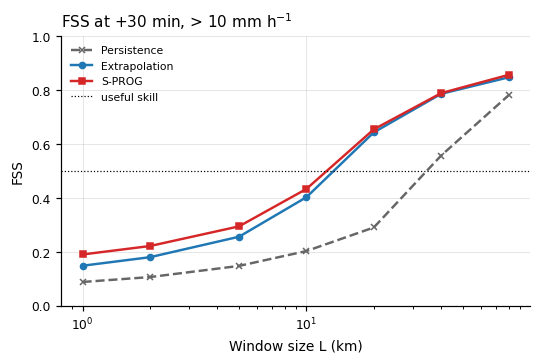

In [11]:
#@title ✅ เฉลยแบบฝึกหัด 3.2 (ลองทำเองก่อน! ดับเบิลคลิกเพื่อดูโค้ด แล้วกด ▶ เพื่อรัน)
scales = [1, 2, 5, 10, 20, 40, 80]
fig, ax = plt.subplots(figsize=(4.8, 3.2), layout="constrained")
for m in methods:
    vals = []
    for L in scales:
        f = verification.fss_init(10.0, L)
        for i in ISSUES:
            verification.fss_accum(f, np.nan_to_num(all_fc[i][m][1]), np.nan_to_num(R[i + 2]))
        vals.append(verification.fss_compute(f))
    ax.plot(scales, vals, ms=4, label=m, **style[m])
ax.axhline(0.5 + fo / 2, color="k", lw=0.8, ls=":", label="useful skill")
ax.set_xscale("log")
mp.skill_axes(ax, xlabel="Window size L (km)", ylabel="FSS", ylim=(0, 1),
              title="FSS at +30 min, > 10 mm h$^{-1}$")
ax.legend(frameon=False, fontsize=7)
mp.save_figure(fig, "nb3_ex32_fss_scale")
plt.show()

### 🧪 แบบฝึกหัด 3.3: (เสริม) LINDA: nowcast ที่ออกแบบมาสำหรับเซลล์พายุ

**LINDA** ตรวจหาเซลล์พายุ (feature) และสร้างแบบจำลองการเติบโต/สลายตัวเฉพาะที่ จึงออกแบบมาเพื่อพายุแบบนี้โดยตรง
สร้าง LINDA nowcast (deterministic) สำหรับ issue time **12:00 UTC** แล้วทำแผนที่ +30 นาที เทียบกับ observed, extrapolation และ S-PROG และคำนวณ FSS (> 10 mm/h, 20 km) ทุก lead time

⚠️ ใช้เวลาประมาณ 1.5–2 นาที | LINDA รับค่า **mm/h** (ไม่ใช่ dBR) และต้องไม่มี NaN และใส่ `timestep=15`

<details>
<summary><b>💡 คำใบ้ (คลิกเพื่อเปิด)</b></summary>

```python
linda = nowcasts.get_method("linda")
d, m = to_dbr(R[1:5]); V = motion.get_method("LK")(d, verbose=False)
fc_linda = linda(np.nan_to_num(R[2:5]), V, N_LEAD, add_perturbations=False,
                 max_num_features=15, kmperpixel=1.0, timestep=15, num_workers=2)
fc_linda[:, ~radar_mask] = np.nan
```

</details>

In [12]:
# ✍️ แบบฝึกหัด 3.3 — เขียนโค้ดของคุณที่นี่ (ลบ # หน้าบรรทัดแล้วเติมส่วนที่เป็น ...)
# linda = nowcasts.get_method("linda")
# fc_linda = linda(...)
# fc_linda[:, ~radar_mask] = np.nan
# ...

Computing LINDA nowcast
-----------------------

Inputs
------
dimensions:           483x483
number of time steps: 3

Methods
-------
nowcast type:         deterministic
feature detector:     blob
extrapolator:         semilagrangian
kernel type:          anisotropic

Parameters
----------
number of time steps:     4
ARI model order:            1
localization window radius: 96.60000000000001
Rain fraction is: 0.013944077946238356, while minimum fraction is 0.0

Detecting features... found 15 blobs.
Transforming to Lagrangian coordinates... done.
Estimating the first convolution kernel... done.
Estimating the ARI(p,1) parameters... done.
Estimating the second convolution kernel... done.
Computing nowcast for time step 1... done.
Computing nowcast for time step 2... done.
Computing nowcast for time step 3... done.
Computing nowcast for time step 4... done.
บันทึกรูปแล้ว: figures/nb3_ex33_linda.png, figures/nb3_ex33_linda.pdf


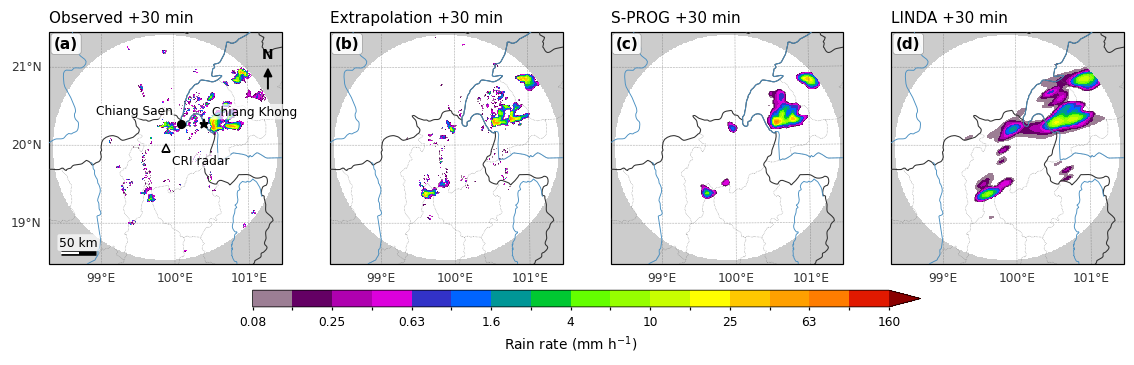

Extrapolation  FSS: +15:0.86  +30:0.67  +45:0.43  +60:0.32
S-PROG         FSS: +15:0.85  +30:0.69  +45:0.34  +60:0.21
LINDA          FSS: +15:0.91  +30:0.76  +45:0.54  +60:0.34


In [13]:
#@title ✅ เฉลยแบบฝึกหัด 3.3 (ลองทำเองก่อน! ดับเบิลคลิกเพื่อดูโค้ด แล้วกด ▶ เพื่อรัน)
linda = nowcasts.get_method("linda")
fc_linda = linda(np.nan_to_num(R[2:5]), V12, N_LEAD, add_perturbations=False,
                 max_num_features=15, kmperpixel=1.0, timestep=15, num_workers=2)
fc_linda[:, ~radar_mask] = np.nan

panels = [("Observed", obs12), ("Extrapolation", fc12["Extrapolation"]),
          ("S-PROG", fc12["S-PROG"]), ("LINDA", fc_linda)]
fig, axs = mp.map_panels(1, 4, meta, panel_width=2.6, zoom=BOX)
for j, (name, data) in enumerate(panels):
    im = mp.radar_map(axs[j], data[1], meta, title=f"{name} +30 min", zoom=BOX,
                      gridline_labels=("left", "bottom") if j == 0 else ("bottom",),
                      north=(j == 0), points=(j == 0), scalebar=(j == 0))
mp.add_colorbar(fig, im, axs); mp.panel_labels(axs)
mp.save_figure(fig, "nb3_ex33_linda")
plt.show()

for name, data in panels[1:]:
    vals = [verification.fss(np.nan_to_num(data[k]), np.nan_to_num(obs12[k]), 10.0, FSS_SCALE) for k in range(N_LEAD)]
    print(f"{name:14s} FSS: " + "  ".join(f"+{int(l)}:{v:.2f}" for l, v in zip(lead_min, vals)))

---
## 📝 สรุป
- กับพายุพาความร้อนที่ข้อมูลห่าง 15 นาที ทักษะของ nowcast **ลดลงเร็วมากภายใน 30–60 นาที**
- Extrapolation ดีกว่า persistence ในช่วงแรก ส่วน S-PROG ลบรายละเอียดเซลล์เล็กเกือบทันที เพราะ autocorrelation ที่ lag 15 นาทีต่ำ
- **FSS** เหมาะกว่าคะแนนแบบ pixel สำหรับพายุเซลล์เล็ก และบอกได้ว่า nowcast "มีประโยชน์" ที่สเกลใด
- Export เป็น **GeoTIFF** ทำให้ใช้งานร่วมกับ GIS ได้ทันที

### ❓ คำถามชวนคิด
1. ถ้า TMD ให้ข้อมูลทุก 5 นาที คาดว่า ETS/FSS จะเปลี่ยนอย่างไร? (ลองทดสอบด้วยข้อมูลที่ interpolate จาก NB2 ได้ แต่ระวังว่ามันไม่ใช่ข้อมูลสังเกตจริง)
2. ทำไมการรวมผลจากหลาย issue time จึงสำคัญในการเขียนบทความวิจัย?

➡️ **บทถัดไป:** Notebook 4 — probabilistic nowcast (STEPS) และความน่าจะเป็นของฝนหนักที่เชียงของ

### 📚 เอกสารอ้างอิง
- Seed, A. W. (2003). A dynamic and spatial scaling approach to advection forecasting. *J. Appl. Meteor.*, 42, 381–388.
- Roberts, N. M., & Lean, H. W. (2008). Scale-selective verification of rainfall accumulations from high-resolution forecasts of convective events. *Mon. Wea. Rev.*, 136, 78–97.
- Pulkkinen, S., et al. (2021). Nowcasting of convective rainfall using volumetric radar observations. *IEEE TGRS*, 58, 7845–7859. (LINDA)